### General code

In [2]:
import time
import gymnasium as gym
import numpy as np

from Simulation.suite_simple_trading.metrics import print_agent_performance
from stable_baselines3 import DQN, PPO, SAC, A2C, DDPG
from Simulation.suite_simple_trading.simulation import run_evaluation, EvaluationResult
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Global Variables
RAW_DATA_PATH = '../../../data/2025_minute.csv'
DATA_SAVE_PATH = "../../../models/used_data"
DAYS_PER_EPISODE = 3
VAL_FRACTION = 0.1
TEST_FRACTION = 0.2  # Amount of data you reserve for testing.

BUFFER_DAYS = 3  # Amount of days that needs to be between different sets.

In [3]:
from Simulation.suite_simple_trading.pre_processing import clean_data
import pandas as pd
import os
from Simulation.suite_simple_trading.data_splitting import get_or_create_train_val_test_split
from Simulation.suite_simple_trading.model import ExtendedBatteryEnv

train_df, val_df_list, test_df_list = get_or_create_train_val_test_split(
    RAW_DATA_PATH,
    DATA_SAVE_PATH,
    DAYS_PER_EPISODE,
    VAL_FRACTION,
    TEST_FRACTION,
    BUFFER_DAYS,
)
val_df_combined = pd.concat(val_df_list, ignore_index=True)
test_df_combined = pd.concat(test_df_list, ignore_index=True)

--- Loading cached cleaned data: ../../../data/2025_minute_cleaned.pkl ---
--- Loading existing split from '../../../models/used_data' ---
Split loaded. Total Test Episodes: 9


In [4]:
class ContinuousActionWrapper(gym.ActionWrapper):
    """
    Wraps a Discrete(3) environment to allow continuous actions for SAC.
    Maps range [-1, 1] to [0, 1, 2].
    """
    def __init__(self, env):
        super().__init__(env)
        # Change the action space to a continuous box
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

    def action(self, continuous_action):
        """
        Maps the continuous output from SAC back to discrete integers.
        """
        if continuous_action < -0.33:
            return 2  # Discharge
        elif continuous_action > 0.33:
            return 1  # Charge
        else:
            return 0  # Idle

### Testing different policy learners
We will do this by outputing multiple runns on increasing number of episodes. By doing this we get a view of the convergence of the different algorithms.
Also, multiple runns will be done so we can see the deviation.

In [5]:
def evaluate_with_statistics(
    env_factory_fn,
    model,
    n_iterations: int = 10,
    number_of_episodes: int = 1,
    is_masked: bool = True
):
    """
    Runs the evaluation multiple times and calculates mean and standard deviation.

    Args:
        env_factory_fn: A function that returns a fresh instance of the scaled environment.
        model: The trained SB3 model.
        n_iterations: Number of full test runs.
        number_of_episodes: Episodes per test run.
        is_masked: Whether the model uses action masking.
    """
    all_run_rewards = []

    print(f"--- Starting Statistical Evaluation ({n_iterations} iterations) ---")

    for i in range(n_iterations):
        # Create a fresh environment for each iteration to ensure independence
        test_env = env_factory_fn()

        # Run evaluation
        result: EvaluationResult = run_evaluation(
            test_env,
            model,
            number_of_episodes=number_of_episodes,
            is_masked=is_masked
        )

        total_reward = sum(result.real_rewards)
        all_run_rewards.append(total_reward)

        print(f"Iteration {i+1}/{n_iterations}: Total Reward = €{total_reward:.2f}")

    # Calculate statistics
    mean_reward = np.mean(all_run_rewards)
    std_reward = np.std(all_run_rewards)

    print(f"\n--- Final Results ---")
    print(f"Mean Total Reward: €{mean_reward:.2f}")
    print(f"Standard Deviation: €{std_reward:.2f}")
    print(f"Relative Variance: {(std_reward / abs(mean_reward)) * 100:.2f}%")

    return all_run_rewards, mean_reward, std_reward

# Define how to build the test environment
def get_val_env(is_continuous=False):
    base_env = ExtendedBatteryEnv(
        battery_capacity_mwh=10.0,
        charge_discharge_rate_mw=5.0,
        all_data=val_df_combined,
        days_per_episode=DAYS_PER_EPISODE
    )
    if is_continuous:
        return ContinuousActionWrapper(base_env)
    return base_env

In [6]:
import time
import pandas as pd
import numpy as np
from stable_baselines3.common.base_class import BaseAlgorithm
from typing import Callable, List, Type, Dict, Any, Union

from Simulation.suite_simple_trading.simulation import run_evaluation, EvaluationResult
import gymnasium as gym

class AgentBenchmarker:
    """
    A utility class for systematically training, evaluating, and recording the
    performance of Reinforcement Learning agents over defined milestones.

    This class handles the repetitive tasks of environment creation, incremental
    training, intermittent validation, and statistical aggregation. It is designed
    to support variable iteration counts per milestone to optimize compute resources
    (e.g., running many tests for early, cheap milestones, and fewer tests for
    later, computationally expensive milestones).

    Attributes:
        train_env_factory (Callable): A function that takes a boolean `is_continuous`
            and returns a fresh, fully-wrapped Gym environment for training.
        val_env_factory (Callable): A function that takes a boolean `is_continuous`
            and returns a fresh, fully-wrapped Gym environment for validation.
        val_episodes_count (int): The number of episodes in the validation dataset.
        csv_path (str): The file path where benchmark results will be saved.
        performance_log (List[Dict]): An internal list storing the aggregated results.
    """
    def __init__(
            self,
            train_env_factory: Callable[[bool], gym.Env],
            val_env_factory: Callable[[bool], gym.Env],
            val_episodes_count: int,
            csv_path: str = "benchmark_results.csv"
    ):
        self.train_env_factory = train_env_factory
        self.val_env_factory = val_env_factory
        self.val_episodes_count = val_episodes_count
        self.csv_path = csv_path
        self.performance_log = []

    def benchmark_agent(
        self,
        agent_name: str,
        agent_class: Type[BaseAlgorithm],
        policy_name: str,
        milestones: List[int],
        iterations_per_milestone: List[int],
        is_masked: bool = False,
        is_continuous: bool = False,
        agent_kwargs: Dict[str, Any] = None
    ):
        """
        Trains an agent from scratch multiple times, evaluating its performance at
        specified step milestones.

        For each milestone, the agent is trained from 0 steps up to that milestone
        in a completely new, independent run. This process is repeated according to
        the `iterations_per_milestone` parameter to calculate statistical variance.

        Args:
            agent_name (str): A string identifier for the agent (e.g., "DQN_Default").
                Used for logging.
            agent_class (Type[BaseAlgorithm]): The SB3 class to instantiate
                (e.g., stable_baselines3.DQN).
            policy_name (str): The policy architecture identifier (e.g., "MlpPolicy").
            milestones (List[int]): A strictly increasing list of total training
                timesteps at which the agent should be evaluated.
            iterations_per_milestone (List[int]): A list of integers matching the length
                of `milestones`. Defines how many independent training runs (from scratch)
                should be executed for the corresponding milestone.
            is_masked (bool, optional): If True, passes `action_masks` to the model
                during evaluation. Required for MaskablePPO. Defaults to False.
            is_continuous (bool, optional): If True, passes `is_continuous=True` to
                the environment factories. Required for SAC/DDPG. Defaults to False.
            agent_kwargs (Dict[str, Any], optional): Additional hyperparameters to
                pass to the `agent_class` constructor (e.g., learning_rate, buffer_size).
                Defaults to None.

        Raises:
            ValueError: If the lengths of `milestones` and `iterations_per_milestone` do not match.
        """
        if len(milestones) != len(iterations_per_milestone):
            raise ValueError(f"Length mismatch: {len(milestones)} milestones provided but {len(iterations_per_milestone)} iteration counts provided.")

        if agent_kwargs is None:
            agent_kwargs = {}

        print(f"\n{'='*60}")
        print(f"Starting Benchmark: {agent_name}")
        print(f"Milestones: {milestones}")
        print(f"Iterations: {iterations_per_milestone}")
        print(f"{'='*60}")

        # Iterate through each milestone
        for i, target_steps in enumerate(milestones):
            n_iterations = iterations_per_milestone[i]
            print(f"\n--- Milestone: {target_steps:,} steps | Running {n_iterations} independent tests ---")

            raw_revenues = []
            train_times = []
            eval_times = []

            # Perform N independent runs for this specific milestone
            for run in range(1, n_iterations + 1):
                # 1. Create a FRESH environment and a FRESH model
                train_env = self.train_env_factory(is_continuous)
                model = agent_class(policy_name, train_env, verbose=0, **agent_kwargs)

                # 2. Train from 0 to the target milestone
                t0_train = time.time()
                model.learn(total_timesteps=target_steps, reset_num_timesteps=True)
                t_train = time.time() - t0_train

                # 3. Evaluate the trained model
                val_env = self.val_env_factory(is_continuous)
                t0_eval = time.time()
                result: EvaluationResult = run_evaluation(
                    val_env,
                    model,
                    number_of_episodes=self.val_episodes_count,
                    is_masked=is_masked
                )
                t_eval = time.time() - t0_eval

                revenue = sum(result.real_rewards)
                print(f"    > Run {run}/{n_iterations} complete. Revenue: €{revenue:.2f}")

                # 4. Store metrics
                raw_revenues.append(revenue)
                train_times.append(t_train)
                eval_times.append(t_eval)

            # 5. Aggregate Results for this milestone
            mean_rev = np.mean(raw_revenues)
            std_rev = np.std(raw_revenues)
            avg_train = np.mean(train_times)
            avg_eval = np.mean(eval_times)

            print(f"  [Aggregation] Mean: €{mean_rev:.2f} ± €{std_rev:.2f}")

            # Append to log
            self.performance_log.append({
                "agent": agent_name,
                "total_steps": target_steps,
                "iterations_run": n_iterations, # Good practice to log how many runs made up this mean
                "mean_revenue": mean_rev,
                "std_revenue": std_rev,
                "train_time_sec": round(avg_train, 2),
                "avg_eval_time_sec": round(avg_eval, 2)
            })

            # Save to CSV after every milestone so data isn't lost if it crashes
            pd.DataFrame(self.performance_log).to_csv(self.csv_path, index=False)

        print(f"\nBenchmark for {agent_name} completed successfully. Data saved to {self.csv_path}")

def create_train_env(is_continuous=False):
    env = ExtendedBatteryEnv(
        battery_capacity_mwh=10.0, charge_discharge_rate_mw=5.0,
        all_data=train_df, days_per_episode=DAYS_PER_EPISODE
    )
    # env = RobustScalingWrapper(env, train_df)
    if is_continuous:
        env = ContinuousActionWrapper(env)
    return env

def create_val_env(is_continuous=False):
    # Ensure val_df_combined is defined (pd.concat(val_episodes_list))
    env = ExtendedBatteryEnv(
        battery_capacity_mwh=10.0, charge_discharge_rate_mw=5.0,
        all_data=val_df_combined, days_per_episode=DAYS_PER_EPISODE
    )
    ## env = RobustScalingWrapper(env, train_df) # ALWAYS fit scaler on train_df!
    if is_continuous:
        env = ContinuousActionWrapper(env)
    return env

def plot_benchmark_results(csv_paths: Union[str, List[str]], title: str = "Agent Convergence: Mean Net Revenue (±2 Std Dev)"):
    """
    Reads benchmark CSV files and plots the mean revenue with standard deviation shading.

    Args:
        csv_paths (str or List[str]): A single path or a list of paths to the CSV files
                                      generated by the AgentBenchmarker.
        title (str): The title for the plot.
    """
    # 1. Load and combine data
    if isinstance(csv_paths, str):
        df = pd.read_csv(csv_paths)
    else:
        # If it's a list, read all and concatenate them into one DataFrame
        dfs = [pd.read_csv(path) for path in csv_paths]
        df = pd.concat(dfs, ignore_index=True)

    # 2. Set professional styling
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Define a custom color palette
    unique_agents = df['agent'].unique()
    colors = sns.color_palette("husl", len(unique_agents))

    # Keep track of min/max values to set the y-axis properly
    min_y, max_y = float('inf'), float('-inf')

    # 3. Plot each agent
    for i, agent in enumerate(unique_agents):
        # Sort values to ensure the line draws correctly from left to right
        subset = df[df['agent'] == agent].sort_values(by='total_steps')

        # Calculate upper and lower bounds for shading (95% CI = 2 * std)
        lower_bound = subset['mean_revenue'] - (2 * subset['std_revenue'])
        upper_bound = subset['mean_revenue'] + (2 * subset['std_revenue'])

        # Update min/max for the y-axis limits
        min_y = min(min_y, lower_bound.min())
        max_y = max(max_y, upper_bound.max())

        # Plot the mean line with dots at the exact checkpoints
        ax.plot(
            subset['total_steps'],
            subset['mean_revenue'],
            marker='o',
            linewidth=2,
            label=agent,
            color=colors[i]
        )

        # Plot the standard deviation shading
        ax.fill_between(
            subset['total_steps'],
            lower_bound,
            upper_bound,
            color=colors[i],
            alpha=0.2,
            linewidth=0
        )

    # 4. Formatting
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel("Training Steps", fontsize=12)
    ax.set_ylabel("Validation Revenue (€)", fontsize=12)

    # Format X and Y axes with comma separators (e.g., 100,000)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))

    # Make the legend look nice
    ax.legend(title="Algorithm", title_fontsize='12', fontsize='11', loc='lower right')

    # Add a line at 0
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    # Add a 5% padding to the Y axis so shading isn't cut off
    y_range = max_y - min_y
    ax.set_ylim(min_y - (y_range * 0.05), max_y + (y_range * 0.05))

    plt.tight_layout()
    plt.show()

### First raw test
Testing all different policy learners a first time

In [7]:
# --- 1. Configuration ---
N_STAT_ITERATIONS = 5  # Number of times to evaluate at each milestone
CHECKPOINTS = [10_000, 90_000, 100_000, 100_000]
TOTAL_MILESTONES = [10_000, 100_000, 200_000, 300_000]

agents_to_test = [
    {"name": "SAC", "class": SAC, "policy": "MlpPolicy", "masked": False, "cont": True},
    {"name": "PPO", "class": PPO, "policy": "MlpPolicy", "masked": False, "cont": False},
    {"name": "DQN", "class": DQN, "policy": "MlpPolicy", "masked": False, "cont": False},
    {"name": "A2C", "class": A2C, "policy": "MlpPolicy", "masked": False, "cont": False},
    {"name": "DDPG", "class": DDPG, "policy": "MlpPolicy", "masked": False, "cont": True},
]


performance_log = []

# --- 3. Execution Loop ---
for agent_info in agents_to_test:
    print(f"\n" + "="*50)
    print(f"AGENT: {agent_info['name']}")
    print("="*50)

    # Setup Training Environment
    train_env_base = ExtendedBatteryEnv(
        battery_capacity_mwh=10.0, charge_discharge_rate_mw=5.0,
        all_data=train_df, days_per_episode=DAYS_PER_EPISODE
    )
    if agent_info['cont']:
        train_env_base = ContinuousActionWrapper(train_env_base)

    # Initialize Model
    model = agent_info['class'](agent_info['policy'], train_env_base, verbose=0)

    start_time_agent = time.time()

    for i, step_increment in enumerate(CHECKPOINTS):
        current_milestone = TOTAL_MILESTONES[i]

        # --- A. Training Phase ---
        start_train = time.time()
        model.learn(total_timesteps=step_increment, reset_num_timesteps=False)
        train_time_total = time.time() - start_train

        # --- B. Statistical Evaluation Phase ---
        milestone_rewards = []
        eval_times = []

        print(f"Evaluating {agent_info['name']} at {current_milestone} steps...")

        for iteration in range(N_STAT_ITERATIONS):
            eval_env = get_val_env(is_continuous=agent_info['cont'])
            iter_start = time.time()

            # Note: deterministic=False if you want to see policy variance,
            # deterministic=True if you only want to see environment variance.
            # Using False here to capture why the agent behaves differently each run.
            result: EvaluationResult = run_evaluation(
                eval_env,
                model,
                number_of_episodes=len(val_df_list),
                is_masked=agent_info['masked']
            )

            milestone_rewards.append(sum(result.real_rewards))
            eval_times.append(time.time() - iter_start)
            print(f"  > Iter {iteration+1}/{N_STAT_ITERATIONS}: €{milestone_rewards[-1]:.2f}")

        # Calculate Statistics
        mean_rev = np.mean(milestone_rewards)
        std_rev = np.std(milestone_rewards)

        # --- C. Logging ---
        performance_log.append({
            "agent": agent_info['name'],
            "total_steps": current_milestone,
            "mean_revenue": mean_rev,
            "std_revenue": std_rev,
            "train_time_sec": round(train_time_total, 2),
            "avg_eval_time_sec": round(np.mean(eval_times), 2)
        })

        print(f"RESULT: Mean €{mean_rev:.2f} (±€{std_rev:.2f}) | Train Time: {train_time_total:.1f}s")

    print(f"Finished {agent_info['name']} in {time.time() - start_time_agent:.1f}s")


AGENT: SAC


KeyboardInterrupt: 

In [26]:
# --- 4. Export and Summary ---
output_df = pd.DataFrame(performance_log)
output_df.to_csv("statistical_comparison_results.csv", index=False)

print("\n" + "="*50)
print("FINAL SUMMARY (Sorted by Mean Revenue)")
print("="*50)
print(output_df[output_df['total_steps'] == TOTAL_MILESTONES[-1]].sort_values(by="mean_revenue", ascending=False))


FINAL SUMMARY (Sorted by Mean Revenue)
   agent  total_steps   mean_revenue  std_revenue  train_time_sec  \
3    SAC       300000  105757.837767   448.968123          951.52   
15   A2C       300000   83018.959242    25.460777           84.04   
7    PPO       300000   78997.680492   462.768734           74.25   
11   DQN       300000   17967.931933    78.978624           54.83   
19  DDPG       300000       0.000000     0.000000          849.98   

    avg_eval_time_sec  
3               25.39  
15              25.91  
7               25.94  
11              14.29  
19              19.75  


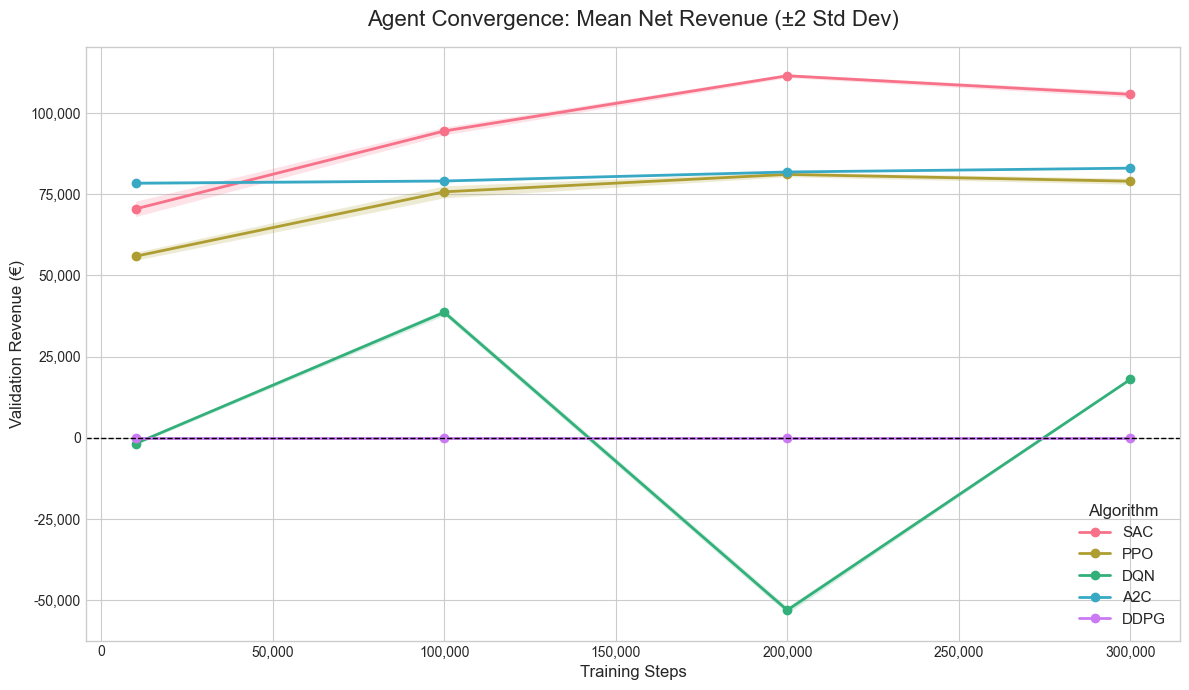

In [10]:
# 1. Read the data
df = pd.read_csv("statistical_comparison_results.csv")

# 2. Set professional styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Define a custom color palette so lines and fills match perfectly
colors = sns.color_palette("husl", len(df['agent'].unique()))

# 3. Plot each agent
for i, agent in enumerate(df['agent'].unique()):
    subset = df[df['agent'] == agent]

    # Plot the mean line with dots at the exact checkpoints
    line, = ax.plot(
        subset['total_steps'],
        subset['mean_revenue'],
        marker='o',          # Adds a dot at 10k, 100k, etc.
        linewidth=2,
        label=agent,
        color=colors[i]
    )

    # Plot the standard deviation shading
    # We multiply by 2 to show the 95% Confidence Interval (2 Standard Deviations)
    # This makes the very small variance slightly more visible on the graph
    ax.fill_between(
        subset['total_steps'],
        subset['mean_revenue'] - (2 * subset['std_revenue']),
        subset['mean_revenue'] + (2 * subset['std_revenue']),
        color=colors[i],
        alpha=0.2,           # Transparency
        linewidth=0          # Removes the border of the shaded area
    )

# 4. Formatting
ax.set_title("Agent Convergence: Mean Net Revenue (±2 Std Dev)", fontsize=16, pad=15)
ax.set_xlabel("Training Steps", fontsize=12)
ax.set_ylabel("Validation Revenue (€)", fontsize=12)

# Format X and Y axes with comma separators (e.g., 100,000)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))

# Make the legend look nice
ax.legend(title="Algorithm", title_fontsize='12', fontsize='11', loc='lower right')

# Add a line at 0 to easily see who is losing money (like DQN)
ax.axhline(0, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
plt.show()

### DQN specific test
Previous test shows little deviation, this is because the learning was not done again. We will see what impact this has only on DQN.
DQN is chosen because it had the weirdest results.

In [9]:
# ... (Assuming create_train_env and create_val_env are defined as before) ...

benchmarker = AgentBenchmarker(
    train_env_factory=create_train_env,
    val_env_factory=create_val_env,
    val_episodes_count=len(val_df_list),
    csv_path="dqn_training_variance_bis.csv"
)

# Define the targets
target_milestones = [1_750_000]
# target_milestones = [25_000, 50_000, 75_000, 100_000, 250_000, 500_000, 750_000, 1_000_000, 1_250_000, 1_500_000]
# Define how many independent models to train from scratch at each milestone
# 10 times for the cheap 10k run, down to 3 times for the heavy 500k run.
#iteration_counts =  [30,     30,      30,       25,      20,        20,       15,         15, 10, 10]
iteration_counts = [10]
benchmarker.benchmark_agent(
    agent_name="DQN",
    agent_class=DQN,
    policy_name="MlpPolicy",
    milestones=target_milestones,
    iterations_per_milestone=iteration_counts,
    is_masked=False,
    is_continuous=False,
    agent_kwargs={
        # Your specific DQN hyperparameters go here
    }
)


Starting Benchmark: DQN
Milestones: [1750000]
Iterations: [10]

--- Milestone: 1,750,000 steps | Running 10 independent tests ---
Starting episode 1/19
From 2025-01-30 00:00:00+00:00 to 2025-02-01 23:59:00+00:00
Finished with total (scaled) reward: 2063.38
Starting episode 2/19
From 2025-01-01 00:00:00+00:00 to 2025-01-03 23:59:00+00:00
Finished with total (scaled) reward: 7217.43
Starting episode 3/19
From 2025-08-06 00:00:00+00:00 to 2025-08-08 23:59:00+00:00
Finished with total (scaled) reward: 3925.81
Starting episode 4/19
From 2025-07-22 00:00:00+00:00 to 2025-07-24 23:59:00+00:00
Finished with total (scaled) reward: 2122.99
Starting episode 5/19
From 2025-08-18 00:00:00+00:00 to 2025-08-20 23:59:00+00:00
Finished with total (scaled) reward: 1220.04
Starting episode 6/19
From 2025-06-06 00:00:00+00:00 to 2025-06-08 23:59:00+00:00
Finished with total (scaled) reward: 5667.68
Starting episode 7/19
From 2025-05-11 00:00:00+00:00 to 2025-05-13 23:59:00+00:00
Finished with total (scal

In [8]:
# ... (Assuming create_train_env and create_val_env are defined as before) ...

benchmarker = AgentBenchmarker(
    train_env_factory=create_train_env,
    val_env_factory=create_val_env,
    val_episodes_count=len(val_df_list),
    csv_path="sac_training_variance_bis4.csv"
)

# Define the targets
# target_milestones = [25_000, 50_000, 75_000, 100_000, 250_000, 500_000, 750_000, 1_000_000, 1_250_000, 1_500_000]
target_milestones = [250_000]
iteration_counts =  [5]
# Define how many independent models to train from scratch at each milestone
# 10 times for the cheap 10k run, down to 3 times for the heavy 500k run.
#iteration_counts =  [30,     30,      30,       25,      20,        20,       15,         15, 10, 10]
benchmarker.benchmark_agent(
    agent_name="SAC",
    agent_class=SAC,
    policy_name="MlpPolicy",
    milestones=target_milestones,
    iterations_per_milestone=iteration_counts,
    is_masked=False,
    is_continuous=True,
    agent_kwargs={
        # Your specific DQN hyperparameters go here
    }
)


Starting Benchmark: SAC
Milestones: [250000]
Iterations: [5]

--- Milestone: 250,000 steps | Running 5 independent tests ---


KeyboardInterrupt: 

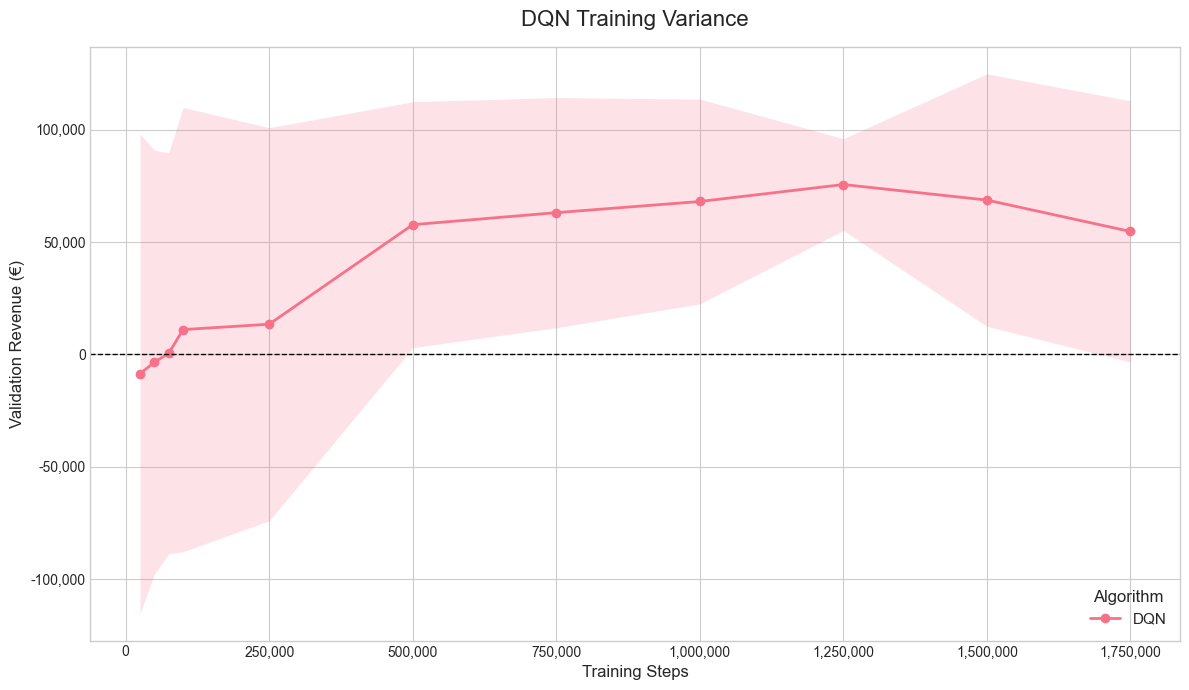

In [17]:
plot_benchmark_results("dqn_training_variance.csv", title="DQN Training Variance")

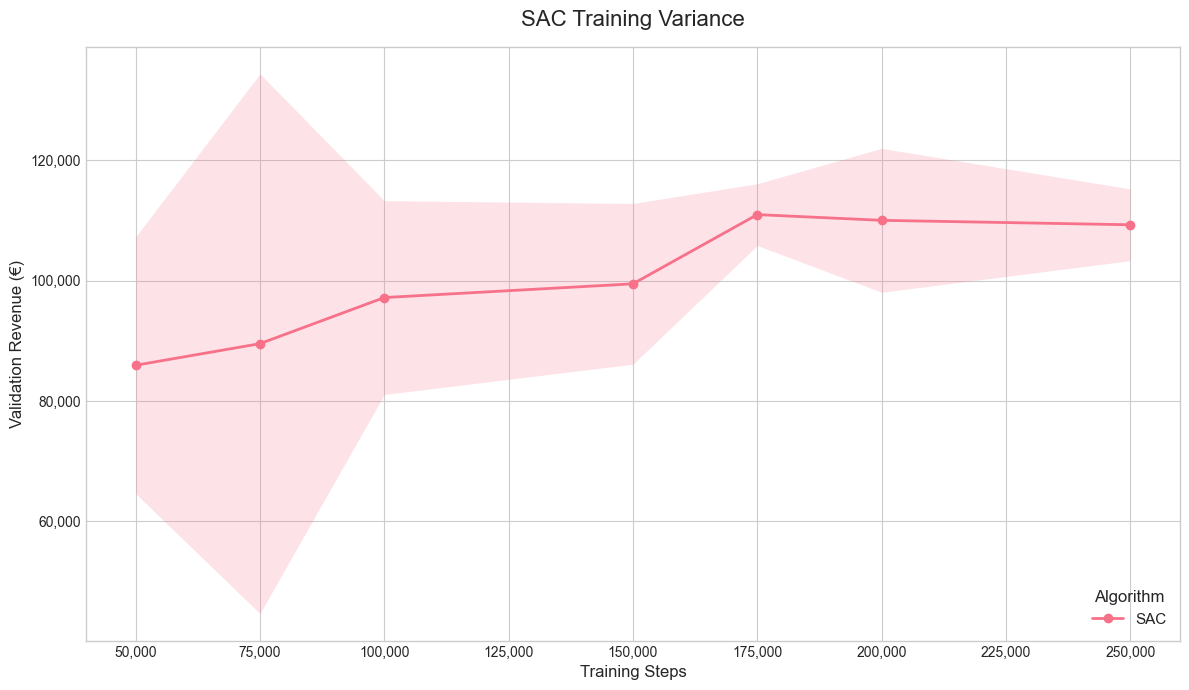

In [15]:
plot_benchmark_results("sac_training_variance.csv", title="SAC Training Variance")


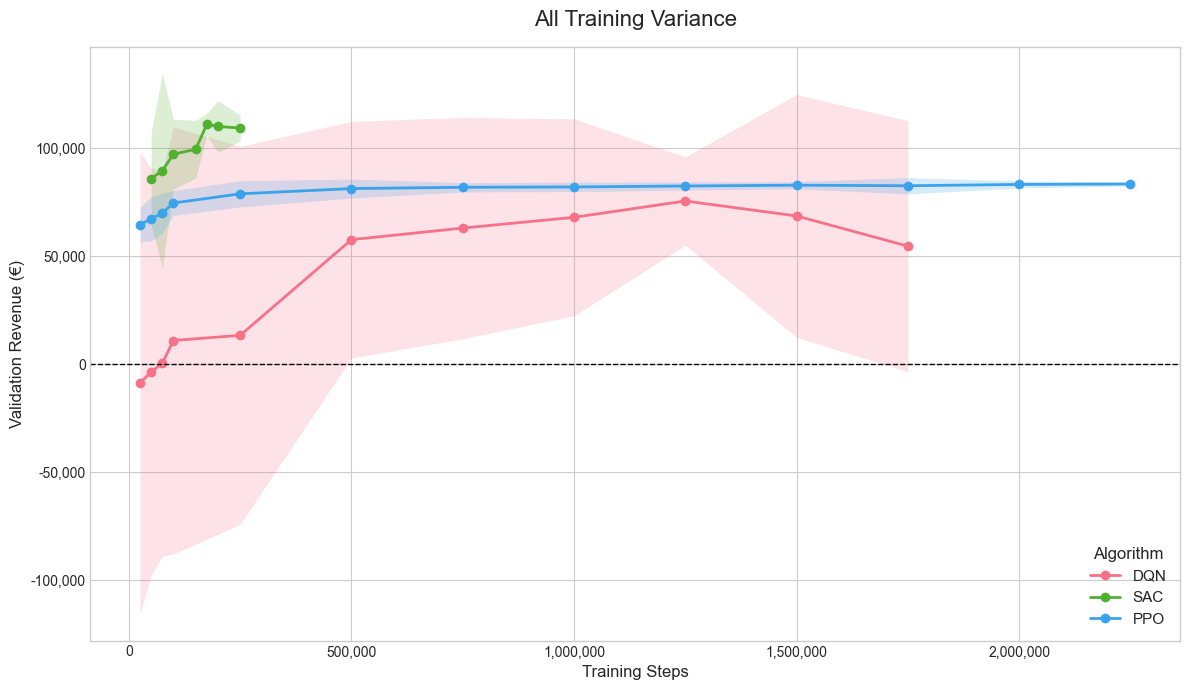

In [7]:
plot_benchmark_results("dqn_training_variance.csv", title="All Training Variance")

## PPO

In [6]:
# ... (Assuming create_train_env and create_val_env are defined as before) ...

benchmarker = AgentBenchmarker(
    train_env_factory=create_train_env,
    val_env_factory=create_val_env,
    val_episodes_count=len(val_df_list),
    csv_path="PPO_training_variance_bis.csv"
)

# Define the targets
target_milestones = [1_750_000, 2_250_000]
# Define how many independent models to train from scratch at each milestone
# 10 times for the cheap 10k run, down to 3 times for the heavy 500k run.
iteration_counts =  [         10, 5]
benchmarker.benchmark_agent(
    agent_name="PPO",
    agent_class=PPO,
    policy_name="MlpPolicy",
    milestones=target_milestones,
    iterations_per_milestone=iteration_counts,
    is_masked=False,
    is_continuous=True,
    agent_kwargs={
        # Your specific DQN hyperparameters go here
    }
)


Starting Benchmark: PPO
Milestones: [1750000, 2250000]
Iterations: [10, 5]

--- Milestone: 1,750,000 steps | Running 10 independent tests ---
Starting episode 1/19
From 2025-01-30 00:00:00+00:00 to 2025-02-01 23:59:00+00:00
Finished with total (scaled) reward: 2619.29
Starting episode 2/19
From 2025-01-01 00:00:00+00:00 to 2025-01-03 23:59:00+00:00
Finished with total (scaled) reward: 11943.91
Starting episode 3/19
From 2025-08-06 00:00:00+00:00 to 2025-08-08 23:59:00+00:00
Finished with total (scaled) reward: 4307.58
Starting episode 4/19
From 2025-07-22 00:00:00+00:00 to 2025-07-24 23:59:00+00:00
Finished with total (scaled) reward: 2416.35
Starting episode 5/19
From 2025-08-18 00:00:00+00:00 to 2025-08-20 23:59:00+00:00
Finished with total (scaled) reward: 1398.36
Starting episode 6/19
From 2025-06-06 00:00:00+00:00 to 2025-06-08 23:59:00+00:00
Finished with total (scaled) reward: 6515.64
Starting episode 7/19
From 2025-05-11 00:00:00+00:00 to 2025-05-13 23:59:00+00:00
Finished wit

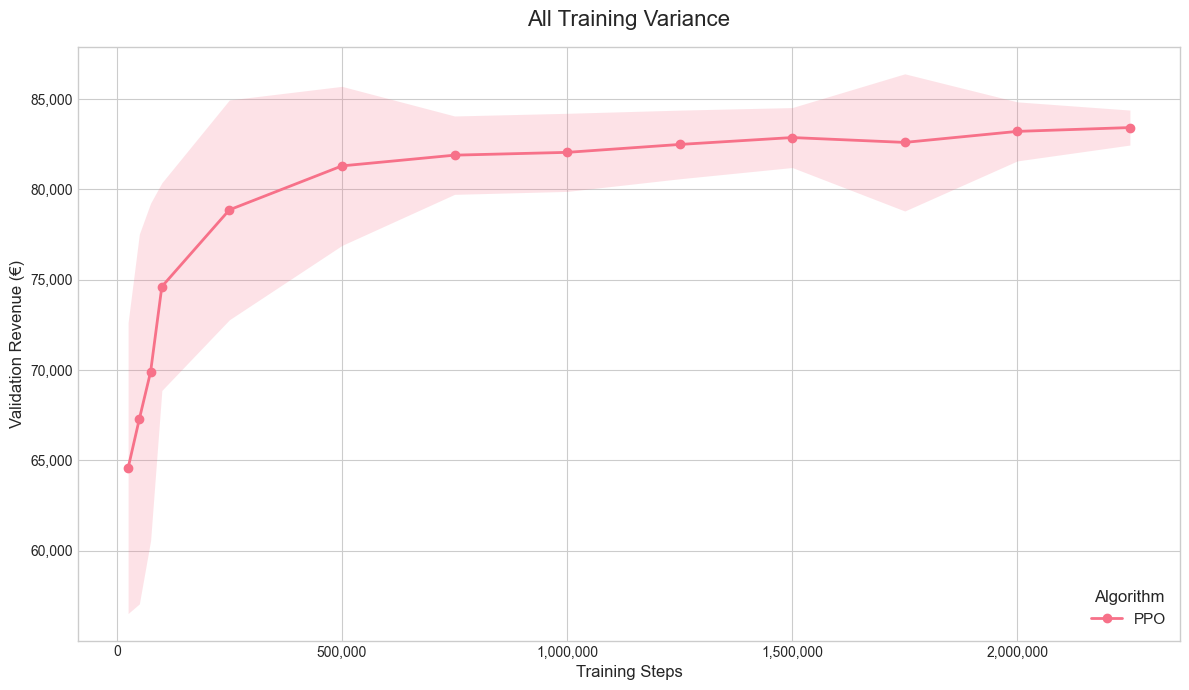

In [8]:
plot_benchmark_results("PPO_training_variance.csv", title="All Training Variance")


## DQN

### Learn 100_000

In [4]:
### The model (Environment) used in all agents

train_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
dqn_agent = DQN(
    policy="MlpPolicy",
    env=train_env_dqn,
)
dqn_agent.learn(100_000)


In [6]:

test_df_combined = pd.concat(test_df_list, ignore_index=True)
test_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df_combined,
    days_per_episode=DAYS_PER_EPISODE
)
result_dqn: EvaluationResult = run_evaluation(test_env_dqn, dqn_agent, number_of_episodes=len(test_df_list), is_masked=False)

Starting episode 1/9
From 2025-09-02 00:00:00+00:00 to 2025-09-04 23:59:00+00:00
Finished with total (scaled) reward: -2643.06
Starting episode 2/9
From 2025-01-18 00:00:00+00:00 to 2025-01-20 23:59:00+00:00
Finished with total (scaled) reward: -4916.53
Starting episode 3/9
From 2025-04-11 00:00:00+00:00 to 2025-04-13 23:59:00+00:00
Finished with total (scaled) reward: -4393.41
Starting episode 4/9
From 2025-03-22 00:00:00+00:00 to 2025-03-24 23:59:00+00:00
Finished with total (scaled) reward: -8816.78
Starting episode 5/9
From 2025-02-28 00:00:00+00:00 to 2025-03-02 23:59:00+00:00
Finished with total (scaled) reward: -2080.40
Starting episode 6/9
From 2025-06-27 00:00:00+00:00 to 2025-06-29 23:59:00+00:00
Finished with total (scaled) reward: -2978.01
Starting episode 7/9
From 2025-07-26 00:00:00+00:00 to 2025-07-28 23:59:00+00:00
Finished with total (scaled) reward: -309.57
Starting episode 8/9
From 2025-05-31 00:00:00+00:00 to 2025-06-02 23:59:00+00:00
Finished with total (scaled) re

In [7]:
print_agent_performance(result_dqn.to_pandas(), "PPO Agent Compare")

  PERFORMANCE REPORT: PPO Agent Compare
  Pos. Profit Quarters : 227
  Neg. Profit Quarters : 396
----------------------------------------
  Success Rate (Active): 36.44%
  Mean Reward / active Quarter: €-27.7972
  Mean Daily Reward    : €-1410.3758
----------------------------------------
  Battery Cycles       : 50.86
  Profit per Cycle     : €-748.36
----------------------------------------
  'Trap' Quarters      : 38
  (Started good -> Ended bad)



### Learn 500_000

In [9]:
dqn_agent.learn(500_000)
result_dqn: EvaluationResult = run_evaluation(test_env_dqn, dqn_agent, number_of_episodes=len(test_df_list), is_masked=False)

Starting episode 1/9
From 2025-09-02 00:00:00+00:00 to 2025-09-04 23:59:00+00:00
Finished with total (scaled) reward: 5807.89
Starting episode 2/9
From 2025-01-18 00:00:00+00:00 to 2025-01-20 23:59:00+00:00
Finished with total (scaled) reward: -8199.73
Starting episode 3/9
From 2025-04-11 00:00:00+00:00 to 2025-04-13 23:59:00+00:00
Finished with total (scaled) reward: 4064.36
Starting episode 4/9
From 2025-03-22 00:00:00+00:00 to 2025-03-24 23:59:00+00:00
Finished with total (scaled) reward: 1602.69
Starting episode 5/9
From 2025-02-28 00:00:00+00:00 to 2025-03-02 23:59:00+00:00
Finished with total (scaled) reward: 1200.09
Starting episode 6/9
From 2025-06-27 00:00:00+00:00 to 2025-06-29 23:59:00+00:00
Finished with total (scaled) reward: 4385.86
Starting episode 7/9
From 2025-07-26 00:00:00+00:00 to 2025-07-28 23:59:00+00:00
Finished with total (scaled) reward: 1866.90
Starting episode 8/9
From 2025-05-31 00:00:00+00:00 to 2025-06-02 23:59:00+00:00
Finished with total (scaled) reward:

In [22]:
print_agent_performance(result_dqn.to_pandas(), "PPO Agent Compare")



  PERFORMANCE REPORT: PPO Agent Compare
  Pos. Profit Quarters : 468
  Neg. Profit Quarters : 212
----------------------------------------
  Success Rate (Active): 68.82%
  Mean Reward / active Quarter: €-2.0567
  Mean Daily Reward    : €-46.6176
----------------------------------------
  Battery Cycles       : 38.27
  Profit per Cycle     : €-36.55
----------------------------------------
  'Trap' Quarters      : 53
  (Started good -> Ended bad)



### Learn 1_000_000

In [25]:
train_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
dqn_agent = DQN(
    policy="MlpPolicy",
    env=train_env_dqn,
)
dqn_agent.learn(1_000_000)
test_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df_combined,
    days_per_episode=DAYS_PER_EPISODE
)

result_dqn: EvaluationResult = run_evaluation(test_env_dqn, dqn_agent, number_of_episodes=len(test_df), is_masked=False)

KeyboardInterrupt: 

## PPO

### Learn 100_000

In [26]:
### Learn 100_000

### Learn 500_000

In [29]:
train_env_ppo = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
ppo_agent = PPO(
    policy="MlpPolicy",
    env=train_env_ppo,
)
ppo_agent.learn(500_000)
test_env_ppo = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df_combined,
    days_per_episode=DAYS_PER_EPISODE
)
result_ppo: EvaluationResult = run_evaluation(test_env_ppo, ppo_agent, number_of_episodes=len(test_df), is_masked=False)


Starting episode 1/10
From 2025-04-30 00:00:00+00:00 to 2025-05-02 23:59:00+00:00
Finished with total (scaled) reward: 3341.80
Starting episode 2/10
From 2025-09-23 00:00:00+00:00 to 2025-09-25 23:59:00+00:00
Finished with total (scaled) reward: 1264.66
Starting episode 3/10
From 2025-03-01 00:00:00+00:00 to 2025-03-03 23:59:00+00:00
Finished with total (scaled) reward: 4606.93
Starting episode 4/10
From 2025-01-05 00:00:00+00:00 to 2025-01-07 23:59:00+00:00
Finished with total (scaled) reward: 8781.71
Starting episode 5/10
From 2025-06-11 00:00:00+00:00 to 2025-06-13 23:59:00+00:00
Finished with total (scaled) reward: 4908.51
Starting episode 6/10
From 2025-08-01 00:00:00+00:00 to 2025-08-03 23:59:00+00:00
Finished with total (scaled) reward: 7163.90
Starting episode 7/10
From 2025-04-26 00:00:00+00:00 to 2025-04-28 23:59:00+00:00
Finished with total (scaled) reward: 10393.35
Starting episode 8/10
From 2025-03-29 00:00:00+00:00 to 2025-03-31 23:59:00+00:00
Finished with total (scaled)

In [30]:
print_agent_performance(result_ppo.to_pandas(), "PPO Agent Compare")

  PERFORMANCE REPORT: PPO Agent Compare
  Pos. Profit Quarters : 810
  Neg. Profit Quarters : 111
----------------------------------------
  Success Rate (Active): 87.95%
  Mean Reward / active Quarter: €74.5818
  Mean Daily Reward    : €2289.6609
----------------------------------------
  Battery Cycles       : 53.82
  Profit per Cycle     : €1276.17
----------------------------------------
  'Trap' Quarters      : 65
  (Started good -> Ended bad)



## SAC

### 100_000 Learning steps

In [6]:
class ContinuousActionWrapper(gym.ActionWrapper):
    """
    Wraps a Discrete(3) environment to allow continuous actions for SAC.
    Maps range [-1, 1] to [0, 1, 2].
    """
    def __init__(self, env):
        super().__init__(env)
        # Change the action space to a continuous box
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

    def action(self, continuous_action):
        """
        Maps the continuous output from SAC back to discrete integers.
        """
        if continuous_action < -0.33:
            return 2  # Discharge
        elif continuous_action > 0.33:
            return 1  # Charge
        else:
            return 0  # Idle

In [22]:
train_env = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_sac = ContinuousActionWrapper(train_env)

sac_agent = SAC(
    policy="MlpPolicy",
    env=train_env_sac,
)
sac_agent.learn(100_000)



In [23]:
test_env = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df_combined,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_sac = ContinuousActionWrapper(test_env)
result_sac: EvaluationResult = run_evaluation(test_env_sac, sac_agent, number_of_episodes=len(test_df_list), is_masked=False)

Starting episode 1/10
From 2025-04-30 00:00:00+00:00 to 2025-05-02 23:59:00+00:00
Finished with total (scaled) reward: 4104.53
Starting episode 2/10
From 2025-09-23 00:00:00+00:00 to 2025-09-25 23:59:00+00:00
Finished with total (scaled) reward: 1863.88
Starting episode 3/10
From 2025-03-01 00:00:00+00:00 to 2025-03-03 23:59:00+00:00
Finished with total (scaled) reward: 4705.78
Starting episode 4/10
From 2025-01-05 00:00:00+00:00 to 2025-01-07 23:59:00+00:00
Finished with total (scaled) reward: 9823.41
Starting episode 5/10
From 2025-06-11 00:00:00+00:00 to 2025-06-13 23:59:00+00:00
Finished with total (scaled) reward: 5746.72
Starting episode 6/10
From 2025-08-01 00:00:00+00:00 to 2025-08-03 23:59:00+00:00
Finished with total (scaled) reward: 7204.51
Starting episode 7/10
From 2025-04-26 00:00:00+00:00 to 2025-04-28 23:59:00+00:00
Finished with total (scaled) reward: 10620.87
Starting episode 8/10
From 2025-03-29 00:00:00+00:00 to 2025-03-31 23:59:00+00:00
Finished with total (scaled)

In [18]:
print_agent_performance(result_sac.to_pandas(), "SAC Agent Compare")

  PERFORMANCE REPORT: SAC Agent Compare
  Pos. Profit Quarters : 756
  Neg. Profit Quarters : 113
----------------------------------------
  Success Rate (Active): 87.00%
  Mean Reward / active Quarter: €76.6089
  Mean Daily Reward    : €2219.1048
----------------------------------------
  Battery Cycles       : 49.63
  Profit per Cycle     : €1341.30
----------------------------------------
  'Trap' Quarters      : 71
  (Started good -> Ended bad)



In [21]:
print_agent_performance(result_sac.to_pandas(), "SAC Agent Compare")

  PERFORMANCE REPORT: SAC Agent Compare
  Pos. Profit Quarters : 1232
  Neg. Profit Quarters : 639
----------------------------------------
  Success Rate (Active): 65.85%
  Mean Reward / active Quarter: €38.6449
  Mean Daily Reward    : €2410.1530
----------------------------------------
  Battery Cycles       : 86.77
  Profit per Cycle     : €833.24
----------------------------------------
  'Trap' Quarters      : 68
  (Started good -> Ended bad)



In [24]:
print_agent_performance(result_sac.to_pandas(), "SAC Agent Compare")

  PERFORMANCE REPORT: SAC Agent Compare
  Pos. Profit Quarters : 1467
  Neg. Profit Quarters : 785
----------------------------------------
  Success Rate (Active): 65.14%
  Mean Reward / active Quarter: €31.9266
  Mean Daily Reward    : €2396.6237
----------------------------------------
  Battery Cycles       : 106.44
  Profit per Cycle     : €675.48
----------------------------------------
  'Trap' Quarters      : 71
  (Started good -> Ended bad)



## DDPG

## A2C